# Vulnerable Informal Settlement Ranking - Random Forest MVP

This notebook trains a Random Forest classifier on the geospatial feature table built from Sentinel-2/SRTM and OSM data.

**Important MVP caveat:** the current dataset does not include field-validated vulnerability labels. For this prototype, we create a transparent proxy vulnerability label from the physical indicators. This is useful for testing the modeling, ranking, dashboard, and API workflow, but it should be replaced with expert-reviewed or field-validated labels before operational use.

## 1. Setup

Install requirements from the project root before running the notebook if your environment does not already have them:

```bash
pip install -r requirements.txt
```

The next cell is intentionally commented so a full notebook run does not unexpectedly trigger package downloads.

In [ ]:
# Optional setup, run manually only if imports fail:
# %pip install -r ../requirements.txt
# %pip install -r requirements.txt

In [11]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

# The notebook is designed to run from either the project root or the notebooks/ folder.
cwd = Path.cwd()
if cwd.name == 'notebooks':
    PROJECT_ROOT = cwd.parent
elif (cwd / 'data').exists() and (cwd / 'notebooks').exists():
    PROJECT_ROOT = cwd
else:
    PROJECT_ROOT = Path('outputs/kigali_vulnerability_mvp')

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

FEATURES_PATH = DATA_DIR / 'real_features.csv'
COORDS_PATH = DATA_DIR / 'settlement_coordinates.csv'

PROJECT_ROOT, FEATURES_PATH, COORDS_PATH

(PosixPath('/Users/kellia.umuhire/Documents/Codex/2026-06-14/files-mentioned-by-the-user-kigali/outputs/kigali_vulnerability_mvp'),
 PosixPath('/Users/kellia.umuhire/Documents/Codex/2026-06-14/files-mentioned-by-the-user-kigali/outputs/kigali_vulnerability_mvp/data/real_features.csv'),
 PosixPath('/Users/kellia.umuhire/Documents/Codex/2026-06-14/files-mentioned-by-the-user-kigali/outputs/kigali_vulnerability_mvp/data/settlement_coordinates.csv'))

## 2. Load Data

`real_features.csv` contains model features. The coordinate file is joined back only for human-readable metadata such as settlement name, district, latitude, and longitude.

In [12]:
features = pd.read_csv(FEATURES_PATH)
coords = pd.read_csv(COORDS_PATH)

df = coords.merge(features, on='settlement_id', how='inner', validate='one_to_one')

print(df.shape)
display(df.head())
display(df.isna().sum())

(192, 14)


,settlement_id,name,district,latitude,longitude,area_hectares,ndvi_real,ndbi_real,mndwi_real,elevation_m_real,slope_degrees_real,flood_zone_overlap_real,building_density_per_ha_real,road_density_m_per_ha_real
0,S050,Rwezamenyo Zone B,Nyarugenge,-1.963695,30.038078,12.63,0.597908,-0.186142,-0.469247,1825.379395,11.443491,0.000000,0.237912,14.502174
1,S008,Agatare Zone H,Nyarugenge,-1.960184,30.031313,19.08,0.353700,0.034665,-0.497007,1656.727173,10.224441,0.000000,12.021398,139.771062
2,S128,Kacyiru Zone H,Gasabo,-1.952674,30.068431,12.34,0.461629,-0.051239,-0.451484,1494.922485,6.969323,0.001250,6.493408,164.143312
3,S057,Gitega Zone A,Nyarugenge,-1.942262,30.027839,13.73,0.446637,-0.100464,-0.404854,1484.107178,21.672150,0.000000,0.948354,74.923808
4,S059,Gitega Zone C,Nyarugenge,-1.989307,30.065176,16.18,0.253737,0.085778,-0.481567,1600.856812,10.123442,0.000473,10.647504,170.650263


settlement_id                   0
name                            0
district                        0
latitude                        0
longitude                       0
area_hectares                   0
ndvi_real                       3
ndbi_real                       3
mndwi_real                      3
elevation_m_real                3
slope_degrees_real              3
flood_zone_overlap_real         3
building_density_per_ha_real    0
road_density_m_per_ha_real      0
dtype: int64

## 3. Define Features

The model uses only geospatial/physical indicators. `name`, `district`, and coordinates are kept for output interpretation but are not used as predictors.

In [13]:
feature_cols = [
    'ndvi_real',
    'ndbi_real',
    'mndwi_real',
    'elevation_m_real',
    'slope_degrees_real',
    'flood_zone_overlap_real',
    'building_density_per_ha_real',
    'road_density_m_per_ha_real',
]

X_raw = df[feature_cols].copy()
X_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
ndvi_real,189.0,0.346986,0.121938,0.111735,0.256691,0.339718,0.444580,0.653711
ndbi_real,189.0,0.015369,0.082673,-0.248440,-0.028125,0.035205,0.075880,0.163175
mndwi_real,189.0,-0.452657,0.047416,-0.559138,-0.484207,-0.455281,-0.419781,-0.315179
elevation_m_real,189.0,1504.181066,100.611885,1350.685547,1437.433716,1477.360718,1537.476562,1837.614746
slope_degrees_real,189.0,9.889501,5.146490,1.771074,6.353412,8.823314,11.606068,26.234446
flood_zone_overlap_real,189.0,0.000766,0.005748,0.000000,0.000000,0.000000,0.000000,0.076800
building_density_per_ha_real,192.0,9.494886,11.455323,0.000000,1.491269,5.971467,12.510103,64.276569
road_density_m_per_ha_real,192.0,101.511897,63.434246,0.000000,49.103155,99.134313,152.419789,271.942081


## 4. Data Visualization and Data Engineering

This section audits the training features before modeling. It covers missingness, feature distributions, and pairwise correlations across the physical/geospatial indicators used by the classifier.

,missing_count,missing_share
ndvi_real,3,0.015625
ndbi_real,3,0.015625
mndwi_real,3,0.015625
elevation_m_real,3,0.015625
slope_degrees_real,3,0.015625
flood_zone_overlap_real,3,0.015625
building_density_per_ha_real,0,0.000000
road_density_m_per_ha_real,0,0.000000


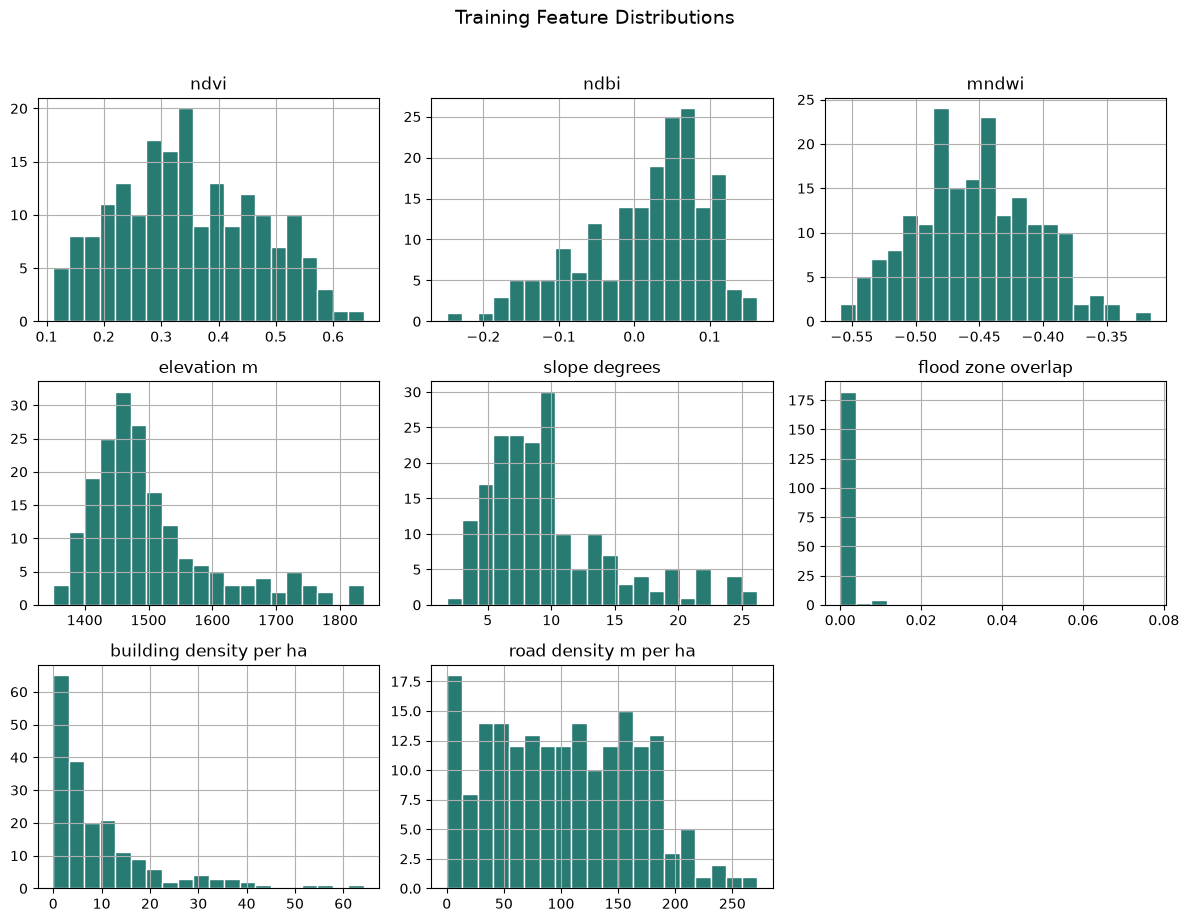

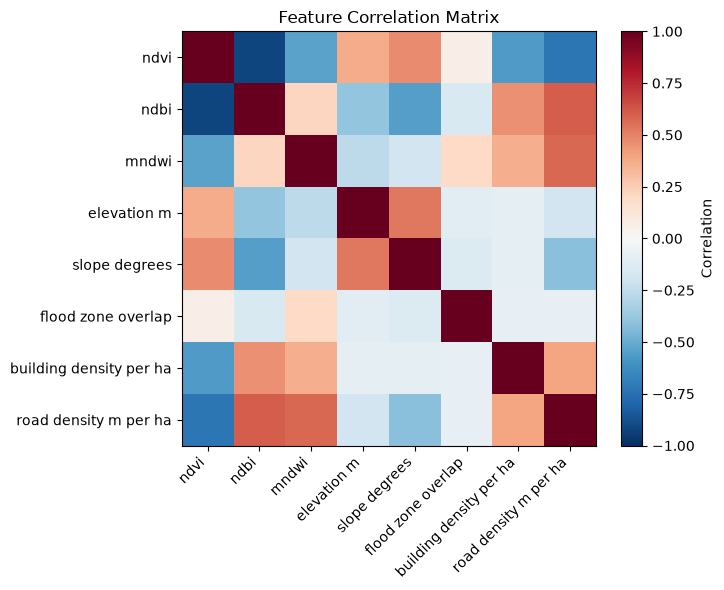

In [14]:
missing_summary = X_raw.isna().sum().rename('missing_count').to_frame()
missing_summary['missing_share'] = missing_summary['missing_count'] / len(X_raw)
display(missing_summary)

axes = X_raw.hist(bins=20, figsize=(12, 9), color='#287b72', edgecolor='white')
for ax in axes.ravel():
    ax.set_title(ax.get_title().replace('_real', '').replace('_', ' '))
plt.suptitle('Training Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

corr = X_raw.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels([c.replace('_real', '').replace('_', ' ') for c in corr.columns], rotation=45, ha='right')
ax.set_yticklabels([c.replace('_real', '').replace('_', ' ') for c in corr.columns])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Create a Transparent Proxy Vulnerability Label

Because there is no validated target label yet, this MVP creates a proxy score from the current indicators. The logic is intentionally simple and auditable:

- higher building density increases vulnerability
- lower NDVI increases vulnerability
- steeper slopes increase vulnerability
- higher flood/wet-pixel overlap increases vulnerability
- higher NDBI increases vulnerability
- lower road density increases vulnerability because it can indicate weaker emergency/service access
- lower elevation gets a small vulnerability weight as a rough flood-exposure proxy

The proxy classes are created by splitting the score into tertiles: Low, Medium, and High.

In [15]:
def minmax(series: pd.Series) -> pd.Series:
    series = series.astype(float)
    denom = series.max() - series.min()
    if pd.isna(denom) or denom == 0:
        return pd.Series(0.0, index=series.index)
    return (series - series.min()) / denom


# Median-fill only for proxy construction and model training. Missingness is preserved in the raw columns.
filled = X_raw.copy()
filled = filled.fillna(filled.median(numeric_only=True))

proxy_components = pd.DataFrame(index=df.index)
proxy_components['building_density_risk'] = minmax(filled['building_density_per_ha_real'])
proxy_components['low_vegetation_risk'] = 1 - minmax(filled['ndvi_real'])
proxy_components['slope_risk'] = minmax(filled['slope_degrees_real'])
proxy_components['flood_overlap_risk'] = minmax(filled['flood_zone_overlap_real'])
proxy_components['built_up_risk'] = minmax(filled['ndbi_real'])
proxy_components['low_road_access_risk'] = 1 - minmax(filled['road_density_m_per_ha_real'])
proxy_components['low_elevation_risk'] = 1 - minmax(filled['elevation_m_real'])

weights = {
    'building_density_risk': 0.25,
    'low_vegetation_risk': 0.20,
    'slope_risk': 0.15,
    'flood_overlap_risk': 0.15,
    'built_up_risk': 0.10,
    'low_road_access_risk': 0.10,
    'low_elevation_risk': 0.05,
}

df['proxy_vulnerability_score'] = 100 * sum(
    proxy_components[col] * weight for col, weight in weights.items()
)

low_cut, high_cut = df['proxy_vulnerability_score'].quantile([1/3, 2/3])
df['proxy_vulnerability_class'] = pd.cut(
    df['proxy_vulnerability_score'],
    bins=[-np.inf, low_cut, high_cut, np.inf],
    labels=['Low', 'Medium', 'High'],
)

display(df[['settlement_id', 'name', 'district', 'proxy_vulnerability_score', 'proxy_vulnerability_class']]
        .sort_values('proxy_vulnerability_score', ascending=False)
        .head(10))
display(df['proxy_vulnerability_class'].value_counts())

,settlement_id,name,district,proxy_vulnerability_score,proxy_vulnerability_class
72,S010,Kimisagara Zone B,Nyarugenge,65.109205,High
102,S152,Kanombe Zone H,Kicukiro,63.885538,High
37,S058,Gitega Zone B,Nyarugenge,59.572261,High
64,S062,Gitega Zone F,Nyarugenge,57.554424,High
21,S024,Nyamirambo Zone H,Nyarugenge,57.091846,High
23,S030,Muhima Zone F,Nyarugenge,55.374271,High
111,S139,Niboye Zone C,Kicukiro,55.120184,High
54,S054,Rwezamenyo Zone F,Nyarugenge,54.813929,High
38,S018,Nyamirambo Zone B,Nyarugenge,54.762497,High
144,S142,Niboye Zone F,Kicukiro,53.121296,High


proxy_vulnerability_class
Low       64
Medium    64
High      64
Name: count, dtype: int64

## 6. Proxy Label Visualization

The charts below show the provisional vulnerability target used for the MVP. These labels are proxy labels and should be replaced with validated vulnerability labels before operational use.

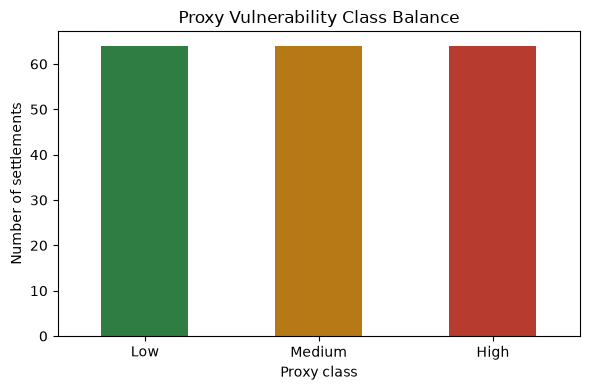

,count,mean,median,max
district,,,,
Kicukiro,64,37.460278,36.239662,63.885538
Nyarugenge,64,37.087555,34.604120,65.109205
Gasabo,64,34.180668,33.851998,50.963884


In [16]:
class_counts = df['proxy_vulnerability_class'].value_counts().reindex(['Low', 'Medium', 'High'])
ax = class_counts.plot.bar(color=['#2f7d42', '#b77916', '#b73b2e'], figsize=(6, 4))
ax.set_title('Proxy Vulnerability Class Balance')
ax.set_xlabel('Proxy class')
ax.set_ylabel('Number of settlements')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

score_by_district = (
    df.groupby('district')['proxy_vulnerability_score']
    .agg(['count', 'mean', 'median', 'max'])
    .sort_values('mean', ascending=False)
)
display(score_by_district)

## 7. Model Architecture

This model is a Random Forest classifier, not a neural network. Therefore, neural-network concepts such as layers, activation functions, and gradient-based optimizers are not applicable here.

Architecture summary:

- `SimpleImputer(strategy='median')` handles missing raster-derived values.
- `RandomForestClassifier` trains an ensemble of 400 decision trees.
- Training uses bootstrap aggregation and feature subsampling across trees.
- `class_weight='balanced'` reduces sensitivity to class imbalance.
- `min_samples_leaf=2` limits overly brittle leaf nodes.
- The model outputs a vulnerability class (`Low`, `Medium`, `High`) plus class probabilities.

In [17]:
model_architecture = pd.DataFrame([
    {'stage': 'Data preprocessing', 'component': 'SimpleImputer', 'setting': 'strategy=median'},
    {'stage': 'Classifier', 'component': 'RandomForestClassifier', 'setting': 'n_estimators=400'},
    {'stage': 'Classifier', 'component': 'RandomForestClassifier', 'setting': 'min_samples_leaf=2'},
    {'stage': 'Classifier', 'component': 'RandomForestClassifier', 'setting': 'class_weight=balanced'},
    {'stage': 'Optimization technique', 'component': 'Tree ensemble', 'setting': 'bootstrap aggregation and feature subsampling'},
    {'stage': 'Layers', 'component': 'Not applicable', 'setting': 'Random Forest is not a layered neural network'},
    {'stage': 'Activation functions', 'component': 'Not applicable', 'setting': 'Decision trees use split rules, not activation functions'},
])
display(model_architecture)

,stage,component,setting
0,Data preprocessing,SimpleImputer,strategy=median
1,Classifier,RandomForestClassifier,n_estimators=400
2,Classifier,RandomForestClassifier,min_samples_leaf=2
3,Classifier,RandomForestClassifier,class_weight=balanced
4,Optimization technique,Tree ensemble,bootstrap aggregation and feature subsampling
5,Layers,Not applicable,Random Forest is not a layered neural network
6,Activation functions,Not applicable,"Decision trees use split rules, not activation..."


## 8. Train/Test Split

The split is stratified so the three proxy classes remain represented in both sets.

In [18]:
X = df[feature_cols]
y = df['proxy_vulnerability_class'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train.shape, X_test.shape, y_train.value_counts().to_dict(), y_test.value_counts().to_dict()

((144, 8),
 (48, 8),
 {'High': 48, 'Low': 48, 'Medium': 48},
 {'Medium': 16, 'Low': 16, 'High': 16})

## 9. Train Random Forest

A `SimpleImputer` handles the three missing raster samples. Random Forests do not require feature scaling.

In [19]:
model = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        (
            'rf',
            RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['ndvi_real','ndbi_real','mndwi_real',...,'flood_zone_overlap_real', 'building_density_per_ha_real','road_density_m_per_ha_real']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is use

## 10. Initial Performance Metrics

These initial metrics evaluate how well the Random Forest recreates the proxy vulnerability label. They include accuracy, precision, recall, F1-score, a classification report, and a confusion matrix. These metrics do not validate real-world vulnerability until field-validated labels are added.

,metric,value
0,accuracy,0.875000
1,precision_macro,0.873950
2,recall_macro,0.875000
3,f1_macro,0.872727
4,precision_weighted,0.873950
5,recall_weighted,0.875000
6,f1_weighted,0.872727


              precision    recall  f1-score   support

        High       0.94      1.00      0.97        16
         Low       0.82      0.88      0.85        16
      Medium       0.86      0.75      0.80        16

    accuracy                           0.88        48
   macro avg       0.87      0.88      0.87        48
weighted avg       0.87      0.88      0.87        48



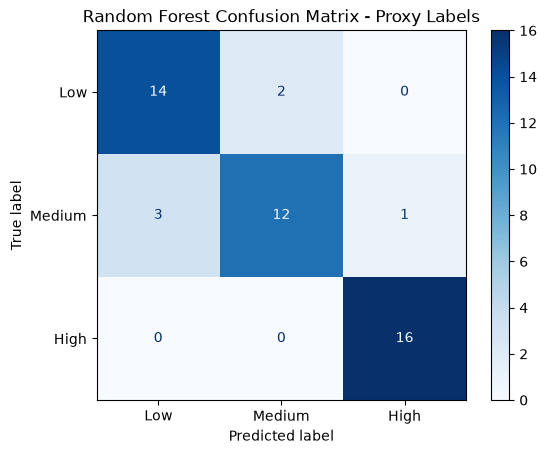

In [20]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='macro', zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted', zero_division=0
)

metrics = pd.DataFrame([
    {'metric': 'accuracy', 'value': accuracy},
    {'metric': 'precision_macro', 'value': macro_precision},
    {'metric': 'recall_macro', 'value': macro_recall},
    {'metric': 'f1_macro', 'value': macro_f1},
    {'metric': 'precision_weighted', 'value': weighted_precision},
    {'metric': 'recall_weighted', 'value': weighted_recall},
    {'metric': 'f1_weighted', 'value': weighted_f1},
])
display(metrics)

print(classification_report(y_test, y_pred, zero_division=0))

labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Random Forest Confusion Matrix - Proxy Labels')
plt.show()

## 11. Feature Importance

Feature importance helps communicate which physical indicators drive the proxy-class model most strongly.

,feature,importance
0,ndvi_real,0.219499
1,ndbi_real,0.205422
6,building_density_per_ha_real,0.194557
2,mndwi_real,0.107022
4,slope_degrees_real,0.096588
7,road_density_m_per_ha_real,0.087858
3,elevation_m_real,0.079909
5,flood_zone_overlap_real,0.009145


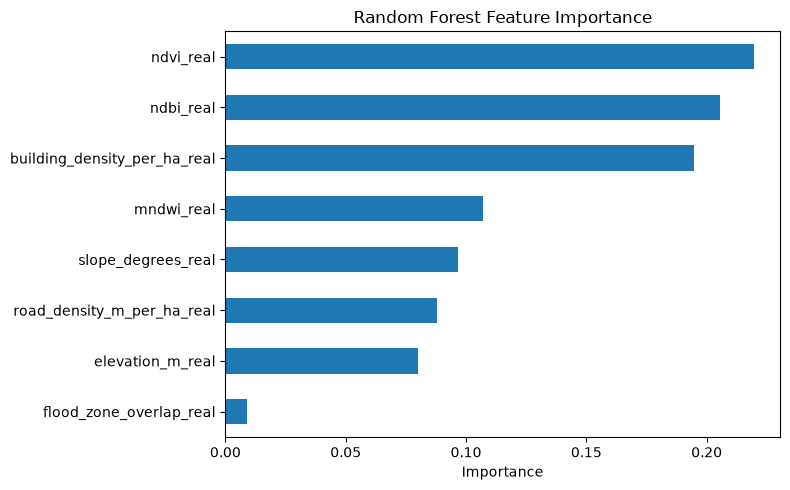

In [21]:
rf = model.named_steps['rf']
importance = pd.DataFrame(
    {
        'feature': feature_cols,
        'importance': rf.feature_importances_,
    }
).sort_values('importance', ascending=False)

display(importance)

ax = importance.sort_values('importance').plot.barh(
    x='feature',
    y='importance',
    figsize=(8, 5),
    legend=False,
)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 12. Score and Rank All Settlements

The ranked output is what the dashboard and API can use in the next MVP steps.

In [22]:
predicted_class = model.predict(X)
predicted_proba = pd.DataFrame(
    model.predict_proba(X),
    columns=[f'probability_{c.lower()}' for c in model.classes_],
    index=df.index,
)

ranking = pd.concat([df, predicted_proba], axis=1)
ranking['predicted_vulnerability_class'] = predicted_class
ranking['vulnerability_rank'] = ranking['proxy_vulnerability_score'].rank(
    method='first',
    ascending=False,
).astype(int)

ordered_cols = [
    'vulnerability_rank',
    'settlement_id',
    'name',
    'district',
    'latitude',
    'longitude',
    'area_hectares',
    'proxy_vulnerability_score',
    'proxy_vulnerability_class',
    'predicted_vulnerability_class',
] + [c for c in predicted_proba.columns] + feature_cols

ranking = ranking[ordered_cols].sort_values('vulnerability_rank')

display(ranking.head(15))

,vulnerability_rank,settlement_id,name,district,latitude,longitude,area_hectares,proxy_vulnerability_score,proxy_vulnerability_class,predicted_vulnerability_class,...,probability_low,probability_medium,ndvi_real,ndbi_real,mndwi_real,elevation_m_real,slope_degrees_real,flood_zone_overlap_real,building_density_per_ha_real,road_density_m_per_ha_real
72,1,S010,Kimisagara Zone B,Nyarugenge,-1.966358,30.055555,28.61,65.109205,High,High,...,0.000000,0.005833,0.127787,0.133268,-0.389479,1496.851929,7.831286,0.0,64.276569,157.368534
102,2,S152,Kanombe Zone H,Kicukiro,-1.961015,30.047611,20.82,63.885538,High,High,...,0.002250,0.034982,0.154882,0.100331,-0.379583,1561.523315,12.902774,0.0,53.832832,97.736346
37,3,S058,Gitega Zone B,Nyarugenge,-1.953335,30.049830,17.36,59.572261,High,High,...,0.001667,0.008000,0.148888,0.108278,-0.380994,1472.966919,13.573220,0.0,38.483448,99.854708
64,4,S062,Gitega Zone F,Nyarugenge,-1.968144,30.077042,22.06,57.554424,High,High,...,0.008839,0.044220,0.163769,0.121772,-0.393536,1462.296509,5.921134,0.0,56.981790,219.752387
21,5,S024,Nyamirambo Zone H,Nyarugenge,-1.952841,30.045106,20.76,57.091846,High,High,...,0.011458,0.166173,0.234575,0.054922,-0.396093,1528.746338,19.063633,0.0,33.193952,66.094608
23,6,S030,Muhima Zone F,Nyarugenge,-1.942851,30.049183,23.61,55.374271,High,High,...,0.000000,0.030940,0.132996,0.125852,-0.389219,1408.119385,10.197243,0.0,36.568668,183.137091
111,7,S139,Niboye Zone C,Kicukiro,-1.979491,30.081147,27.01,55.120184,High,High,...,0.000000,0.000000,0.194911,0.097880,-0.426778,1479.148193,9.462139,0.0,42.756544,142.791603
54,8,S054,Rwezamenyo Zone F,Nyarugenge,-1.951636,30.053214,27.53,54.813929,High,High,...,0.002500,0.008958,0.180004,0.097961,-0.403400,1439.940552,11.858186,0.0,32.052917,103.821779
38,9,S018,Nyamirambo Zone B,Nyarugenge,-1.956787,30.050601,18.92,54.762497,High,High,...,0.000000,0.002083,0.148818,0.121520,-0.404498,1483.635986,12.421219,0.0,29.328274,120.448712
144,10,S142,Niboye Zone F,Kicukiro,-1.979699,30.082574,21.53,53.121296,High,High,...,0.000833,0.010208,0.204411,0.085330,-0.417403,1466.312622,10.787995,0.0,33.914183,111.491098


## 13. Save Artifacts

These files can feed the React mockup and the FastAPI service:

- `settlement_vulnerability_rankings.csv`
- `feature_importance.csv`
- `vulnerability_random_forest.joblib`

In [23]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ranking.to_csv(OUTPUT_DIR / 'settlement_vulnerability_rankings.csv', index=False)
importance.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
joblib.dump(
    {
        'model': model,
        'feature_cols': feature_cols,
        'proxy_weights': weights,
        'proxy_low_cut': float(low_cut),
        'proxy_high_cut': float(high_cut),
        'mvp_caveat': 'Proxy labels only; replace with validated vulnerability labels before operational use.',
    },
    MODEL_DIR / 'vulnerability_random_forest.joblib',
)

print('Saved:')
print(OUTPUT_DIR / 'settlement_vulnerability_rankings.csv')
print(OUTPUT_DIR / 'feature_importance.csv')
print(MODEL_DIR / 'vulnerability_random_forest.joblib')

Saved:
/Users/kellia.umuhire/Documents/Codex/2026-06-14/files-mentioned-by-the-user-kigali/outputs/kigali_vulnerability_mvp/outputs/settlement_vulnerability_rankings.csv
/Users/kellia.umuhire/Documents/Codex/2026-06-14/files-mentioned-by-the-user-kigali/outputs/kigali_vulnerability_mvp/outputs/feature_importance.csv
/Users/kellia.umuhire/Documents/Codex/2026-06-14/files-mentioned-by-the-user-kigali/outputs/kigali_vulnerability_mvp/models/vulnerability_random_forest.joblib
